# San Luis Valley aeromagentic levelling

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import cmocean
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

## Load data

In [3]:
data_df = pd.read_csv("data/san_luis_magnetics.csv")

data_df = data_df[::10]

# every x line
data_df = data_df[
    data_df.line.isin(data_df.line.unique()[data_df.line.unique() % 8 == 0])
]

# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry
12160,8,line,37.5147,-105.6384,443561.45,4152165.41,1.099473e+09,2473.94,-857.65,-862.39,POINT (443561.45 4152165.41)
12170,8,line,37.5147,-105.6411,443324.64,4152170.35,1.099473e+09,2473.95,-857.49,-862.23,POINT (443324.64 4152170.35)
12180,8,line,37.5148,-105.6437,443086.93,4152174.19,1.099473e+09,2472.83,-857.01,-861.73,POINT (443086.93 4152174.19)
12190,8,line,37.5148,-105.6464,442850.10,4152176.93,1.099473e+09,2472.34,-857.62,-862.32,POINT (442850.1 4152176.93)
12200,8,line,37.5148,-105.6491,442612.38,4152177.46,1.099473e+09,2470.84,-858.92,-863.57,POINT (442612.38 4152177.46)


In [4]:
data_df.describe()

,line,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa
count,15976.000000,15976.000000,15976.000000,15976.000000,1.597600e+04,1.597600e+04,15976.000000,15976.000000,15976.000000
mean,332.423635,37.076125,-105.812792,427762.557874,4.103637e+06,1.100012e+09,2536.988750,-567.590821,-567.347579
std,201.817913,0.284484,0.161620,14313.224052,3.158150e+04,1.874690e+06,100.408703,223.764921,221.360477
min,8.000000,36.459500,-106.170100,396499.230000,4.035269e+06,1.091007e+09,2260.260000,-1913.240000,-1903.470000
25%,160.000000,36.856500,-105.935900,416742.337500,4.079330e+06,1.099473e+09,2474.130000,-702.570000,-701.202500
50%,312.000000,37.111900,-105.813400,427651.625000,4.107691e+06,1.100069e+09,2508.455000,-576.315000,-575.940000
75%,528.000000,37.316300,-105.672400,440184.737500,4.130154e+06,1.101193e+09,2577.210000,-449.782500,-452.257500
max,648.000000,37.544400,-105.457800,459404.030000,4.155896e+06,1.102069e+09,3110.060000,2059.910000,1953.840000


In [5]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df, easting_column="easting", northing_column="northing", groupby_column="line"
)
data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry,distance_along_line
12160,8,line,37.5147,-105.6384,443561.45,4152165.41,1.099473e+09,2473.94,-857.65,-862.39,POINT (443561.45 4152165.41),0.000000
12170,8,line,37.5147,-105.6411,443324.64,4152170.35,1.099473e+09,2473.95,-857.49,-862.23,POINT (443324.64 4152170.35),236.861520
12180,8,line,37.5148,-105.6437,443086.93,4152174.19,1.099473e+09,2472.83,-857.01,-861.73,POINT (443086.93 4152174.19),474.602534
12190,8,line,37.5148,-105.6464,442850.10,4152176.93,1.099473e+09,2472.34,-857.62,-862.32,POINT (442850.1 4152176.93),711.448384
12200,8,line,37.5148,-105.6491,442612.38,4152177.46,1.099473e+09,2470.84,-858.92,-863.57,POINT (442612.38 4152177.46),949.168974


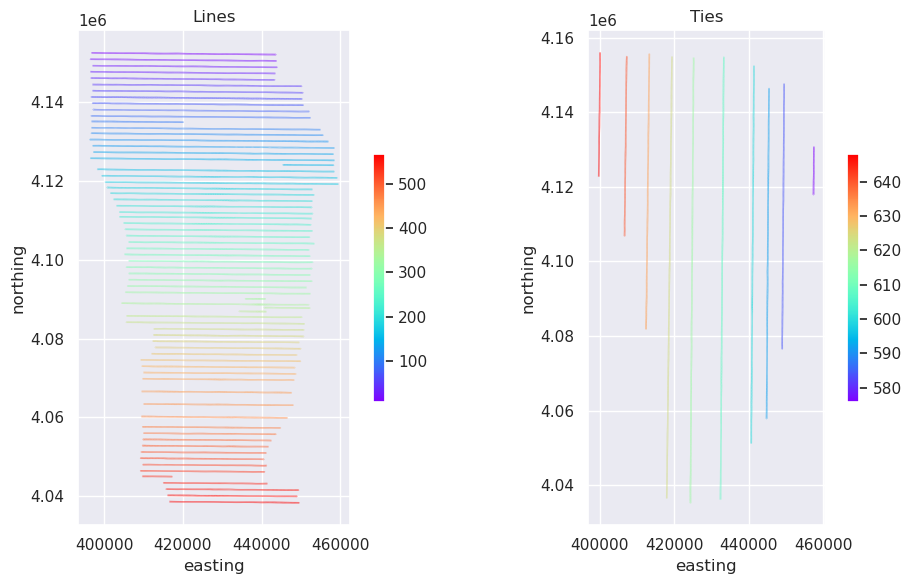

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

df = data_df  # [::10]
df = df[df.line_type == "line"]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[0],
    colorbar=False,
    title="Lines",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

df = data_df  # [::10]
df = df[df.line_type == "tie"]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[1],
    colorbar=False,
    title="Ties",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

# Cross-over levelling

## Find intersections

Line/tie combinations:   0%|          | 0/710 [00:00<?, ?it/s]

Potential intersections:   0%|          | 0/444 [00:00<?, ?it/s]

INFO:airbornegeo:found 444 intersections


,line,tie,geometry,max_dist,easting,northing
0,8,600,POINT (441372 4152183),116.290795,441372.0,4152183.0
1,8,608,POINT (433264 4152268),99.307011,433264.0,4152268.0
2,8,616,POINT (425198 4152349),10.290486,425198.0,4152349.0
3,8,624,POINT (419364 4152423),98.493990,419364.0,4152423.0
4,8,632,POINT (413298 4152428),46.140156,413298.0,4152428.0
...,...,...,...,...,...,...
439,560,616,POINT (424347 4040132),105.960618,424347.0,4040132.0
440,560,624,POINT (418045 4040208),65.402723,418045.0,4040208.0
441,568,608,POINT (432403 4038477),54.292034,432403.0,4038477.0
442,568,616,POINT (424336 4038575),54.280111,424336.0,4038575.0


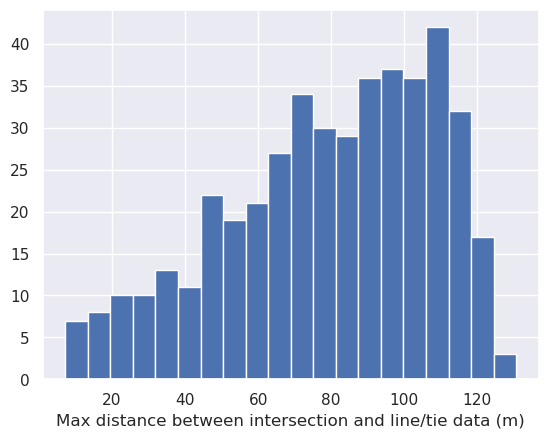

In [7]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    plot_map=False,
)
inters

## Add intersections as rows to the dataframe

In [8]:
data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry,distance_along_line
12160,8,line,37.5147,-105.6384,443561.45,4152165.41,1.099473e+09,2473.94,-857.65,-862.39,POINT (443561.45 4152165.41),0.000000
12170,8,line,37.5147,-105.6411,443324.64,4152170.35,1.099473e+09,2473.95,-857.49,-862.23,POINT (443324.64 4152170.35),236.861520
12180,8,line,37.5148,-105.6437,443086.93,4152174.19,1.099473e+09,2472.83,-857.01,-861.73,POINT (443086.93 4152174.19),474.602534
12190,8,line,37.5148,-105.6464,442850.10,4152176.93,1.099473e+09,2472.34,-857.62,-862.32,POINT (442850.1 4152176.93),711.448384
12200,8,line,37.5148,-105.6491,442612.38,4152177.46,1.099473e+09,2470.84,-858.92,-863.57,POINT (442612.38 4152177.46),949.168974


In [9]:
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    to_interp="unlevelled_tfa",
    window_width=500,
    method="cubic",
    extrapolate=False,
)

Segments:   0%|          | 0/81 [00:00<?, ?it/s]

In [10]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters)

[np.int64(536)]

## Calculate initial cross-over errors

Intersections:   0%|          | 0/444 [00:00<?, ?it/s]

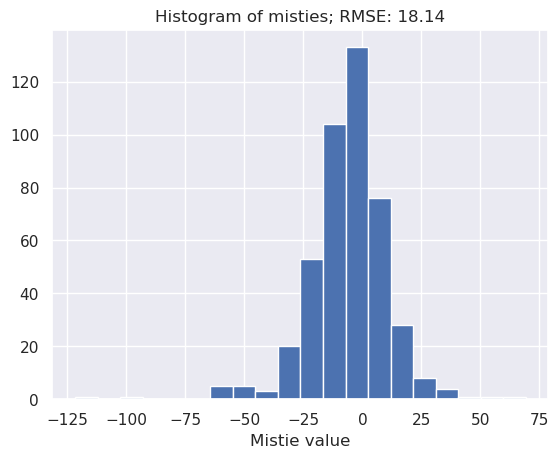

In [11]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    plot_map=False,
)

In [12]:
inters.head()

,line,tie,geometry,max_dist,easting,northing,dist_along_flight_line,dist_along_flight_tie,flight_interpolation_type,tie_interpolation_type,mistie_0
0,8,600,POINT (441372 4152183),116.290795,441372.0,4152183.0,2189.565780,116.290795,interpolated,interpolated,4.765567
1,8,608,POINT (433264 4152268),99.307011,433264.0,4152268.0,10298.043722,2408.039235,interpolated,interpolated,-5.012900
2,8,616,POINT (425198 4152349),10.290486,425198.0,4152349.0,18364.967436,117087.985132,interpolated,interpolated,-4.152693
3,8,624,POINT (419364 4152423),98.493990,419364.0,4152423.0,24199.656470,2363.126582,interpolated,interpolated,0.628518
4,8,632,POINT (413298 4152428),46.140156,413298.0,4152428.0,30265.888765,3100.474216,interpolated,interpolated,-7.660844


## Level lines to ties

In [13]:
# data_df1, inters_lines_to_ties = airbornegeo.crossover_levelling(
#     data_df,
#     inters,
#     lines_to_level=data_df[data_df.line_type == "line"].line.unique(),
#     data_col="unlevelled_tfa",
#     levelled_col="mag_levelled_lines_to_ties_trend0",
#     degree=0,
# )
# inters_lines_to_ties.head()

In [14]:
# inters_lines_to_ties = airbornegeo.calculate_crossover_errors(
#     data_df,
#     inters_lines_to_ties,
#     data_col="mag_levelled_lines_to_ties_trend0",
#     plot_map=False,
# )

In [15]:
# airbornegeo.plot_levelling_convergence(inters_lines_to_ties)

In [16]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 40))

# data_df["levelling_correction"] = (
#     data_df.unlevelled_tfa - data_df.mag_levelled_lines_to_ties_trend0
# )

# df = data_df[::10]

# max_abs = vd.maxabs(data_df.unlevelled_tfa, percentile=95)
# ax = df.plot.scatter(
#     "easting",
#     "northing",
#     c="unlevelled_tfa",
#     s=1,
#     ax=axs[0],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Unlevelled",
# )
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)


# dif_maxabs = vd.maxabs(data_df.levelling_correction, percentile=95)

# ax = df.plot.scatter(
#     "easting",
#     "northing",
#     c="levelling_correction",
#     s=1,
#     ax=axs[1],
#     cmap=cmocean.cm.balance,
#     vmin=-dif_maxabs,
#     vmax=dif_maxabs,
#     colorbar=False,
#     title="Levelling correction",
# )
# ax.set_yticks([])
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# ax = df.plot.scatter(
#     "easting",
#     "northing",
#     c="mag_levelled_lines_to_ties_trend0",
#     s=1,
#     ax=axs[2],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Lines levelled to ties, trend 0",
# )
# ax.set_yticks([])
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# plt.tight_layout()
# plt.show()

## Level ties to lines
We can also level the tie lines to the flight lines. We do this be supplying the `lines_to_level` parameter with the names of the tie lines. We will give this levelled data a new name `mag_levelled_ties_trend0`

In [17]:
# data_df, inters_ties_to_lines = airbornegeo.crossover_levelling(
#     data_df,
#     inters,
#     lines_to_level=data_df[data_df.tie == True].line.unique(),
#     data_col="unlevelled_tfa",
#     levelled_col="mag_levelled_ties_to_lines_trend0",
#     degree=0,
# )
# inters_ties_to_lines.head()

In [18]:
# inters_ties_to_lines = airbornegeo.calculate_crossover_errors(
#     data_df,
#     inters_ties_to_lines,
#     data_col="mag_levelled_ties_to_lines_trend0",
#     plot_map=True,
# )

In [19]:
# airbornegeo.plot_levelling_convergence(inters_ties_to_lines)

In [20]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 40))

# max_abs = vd.maxabs(data_df.mag, percentile=95)
# ax = data_df[::10].plot.scatter(
#     "easting",
#     "northing",
#     c="mag",
#     s=1,
#     ax=axs[0],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Unlevelled",
# )
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# data_df["levelling_correction"] = (
#     data_df.mag - data_df.mag_levelled_ties_to_lines_trend0
# )
# ax = data_df[::10].plot.scatter(
#     "easting",
#     "northing",
#     c="levelling_correction",
#     s=1,
#     ax=axs[1],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Levelling correction",
# )
# ax.set_yticks([])
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# ax = data_df[::10].plot.scatter(
#     "easting",
#     "northing",
#     c="mag_levelled_ties_to_lines_trend0",
#     s=1,
#     ax=axs[2],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Ties levelled to lines, trend 0",
# )
# ax.set_yticks([])
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# plt.tight_layout()
# plt.show()

We can repeat these steps, increasing the trend order if we need more levelling, and alternating between levelling lines or ties. In some case, we want to iteratively repeat the levelling. This is shown below.

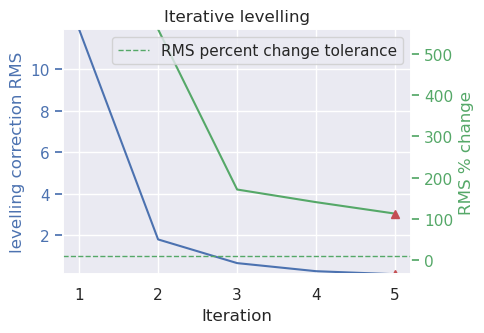

,line,tie,geometry,max_dist,easting,northing,dist_along_flight_line,dist_along_flight_tie,flight_interpolation_type,tie_interpolation_type,...,mistie_1,mistie_2,mistie_3,mistie_4,mistie_5,mistie_6,mistie_7,mistie_8,mistie_9,mistie_10
0,8,600,POINT (441372 4152183),116.290795,441372.0,4152183.0,2189.565780,116.290795,interpolated,interpolated,...,4.616455,2.230147,-0.349215,0.414959,-0.082176,0.066779,-0.113627,-0.087287,-0.187072,-0.184457
1,8,608,POINT (433264 4152268),99.307011,433264.0,4152268.0,10298.043722,2408.039235,interpolated,interpolated,...,-3.883865,3.493439,1.651864,0.988102,0.727946,0.431104,0.371041,0.255900,0.228797,0.185476
2,8,616,POINT (425198 4152349),10.290486,425198.0,4152349.0,18364.967436,117087.985132,interpolated,interpolated,...,-1.752061,3.577764,2.470194,2.571945,2.547555,2.595275,2.654939,2.696430,2.741638,2.773330
3,8,624,POINT (419364 4152423),98.493990,419364.0,4152423.0,24199.656470,2363.126582,interpolated,interpolated,...,3.948877,-6.639603,-7.216277,-6.644181,-6.498046,-6.172085,-6.025824,-5.859097,-5.761588,-5.670539
4,8,632,POINT (413298 4152428),46.140156,413298.0,4152428.0,30265.888765,3100.474216,interpolated,interpolated,...,-3.384258,2.189151,2.164439,2.484658,2.808085,2.782521,3.018815,2.946175,3.098061,3.039669


In [21]:
data_df, inters_alternating_iterative = (
    airbornegeo.alternating_iterative_line_levelling(
        data_df,
        inters,
        data_col="unlevelled_tfa",
        levelled_col="mag_levelled_alternating_trend1",
        degree=1,
        max_iterations=5,
        plot_dynamic_levelling_convergence=True,
    )
)
inters_alternating_iterative.head()

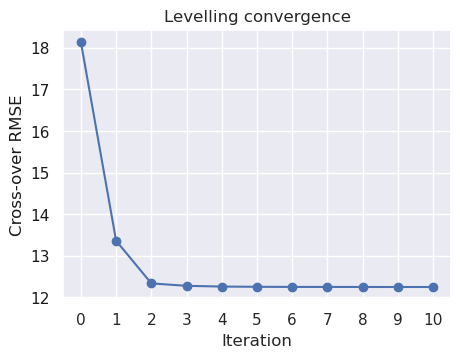

In [22]:
airbornegeo.plot_levelling_convergence(inters_alternating_iterative)

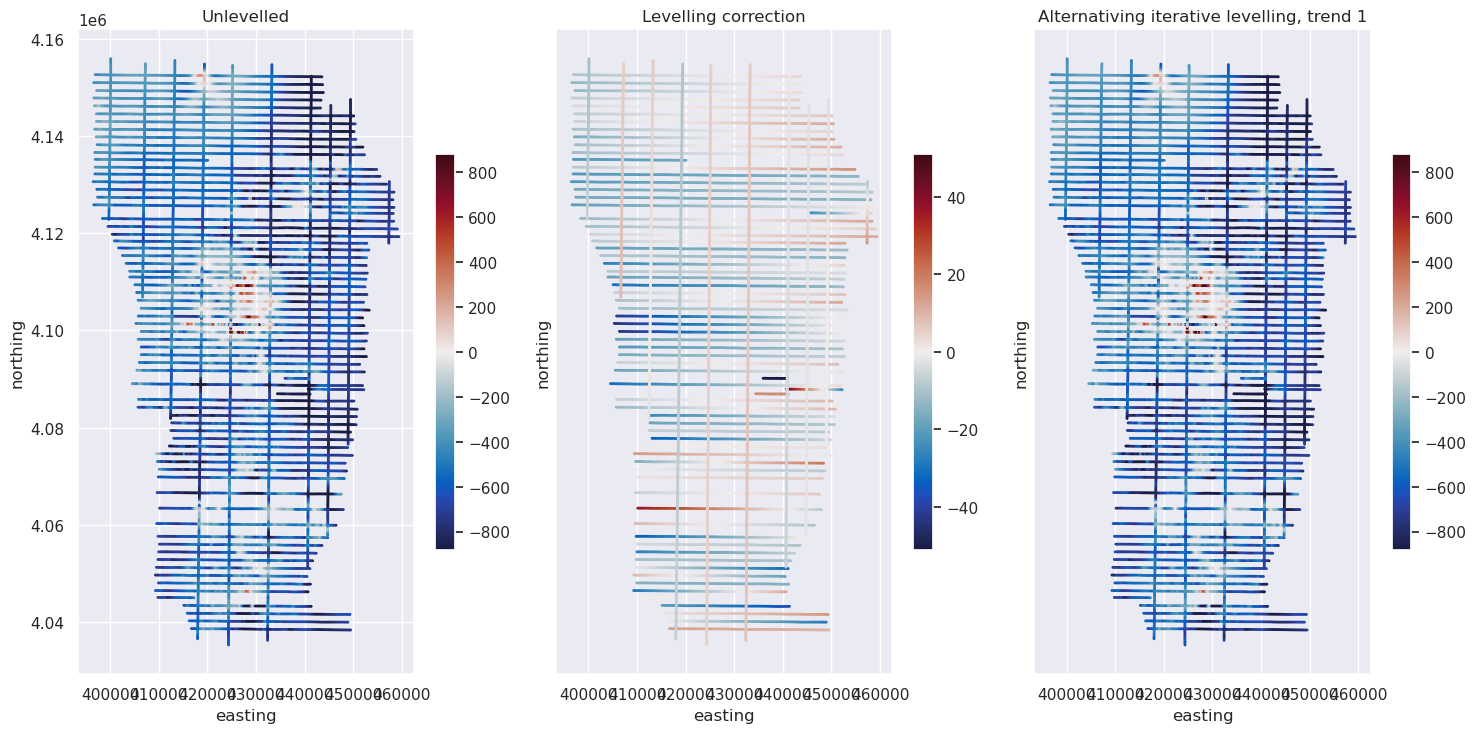

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

max_abs = vd.maxabs(data_df.unlevelled_tfa, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

data_df["levelling_correction"] = (
    data_df.unlevelled_tfa - data_df.mag_levelled_alternating_trend1
)
max_abs_level_corr = vd.maxabs(data_df.levelling_correction, percentile=100)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_levelled_alternating_trend1",
    s=1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Alternativing iterative levelling, trend 1",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()